# Math Behind Neural Networks

Lets look at a simple neural network with one hidden layer. The objective of this network is to accept an 8x8 pixel image of a digit from [MNIST Dataset](https://en.wikipedia.org/wiki/MNIST_database) and output the probability of the digit being 0-9. The network has 3 layers:
- Input layer: 64 tokens (8x8 pixels)
- Hidden layer: 64 nodes
- Output layer: 10 nodes (0-9 digits)

Each input pixel can have a value between `0.0` to `1.0` where `0.0` is black and `1.0` is white. You can consider input value as tokenized value of the pixel. Between input layer and hidden layer, we have 64x64 weights. Between hidden layer and output layer, we have 64x10 weights. The network has `64x64 + 64x10 = 4096` weights in total. Each neuron in the hidden layer and output layer has a bias term. So, we have `64 + 10 = 74` bias terms. The total number of parameters in the network is <br><b>4096 + 74 = 4170 parameters</b>.

![Neural Network](_asset/images/nn_hero_small.gif)

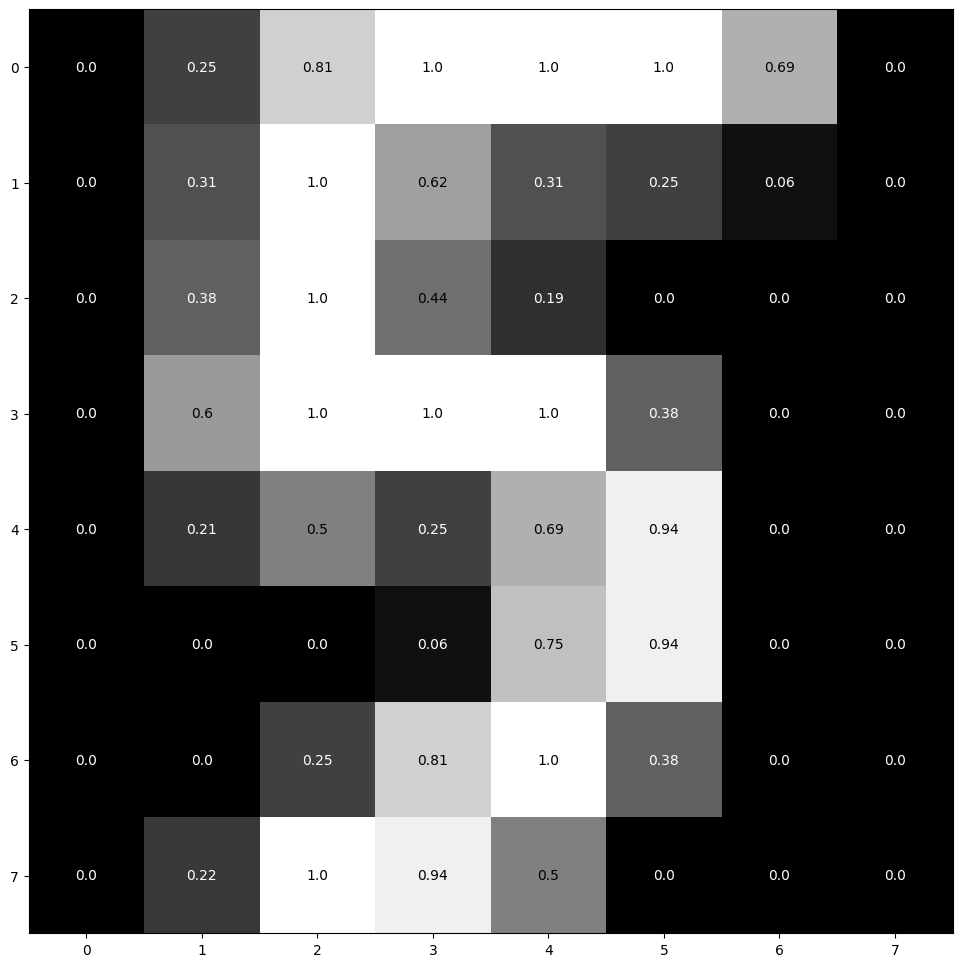

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
import numpy as np

%matplotlib inline

def visualize_input(img, ax):
    ax.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y], 2)), xy=(y, x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y] < thresh else 'black')

digits = load_digits()
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(digits.data)
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111)
visualize_input(normalized_data[32].reshape(8, 8), ax)


## Biological Inspiration

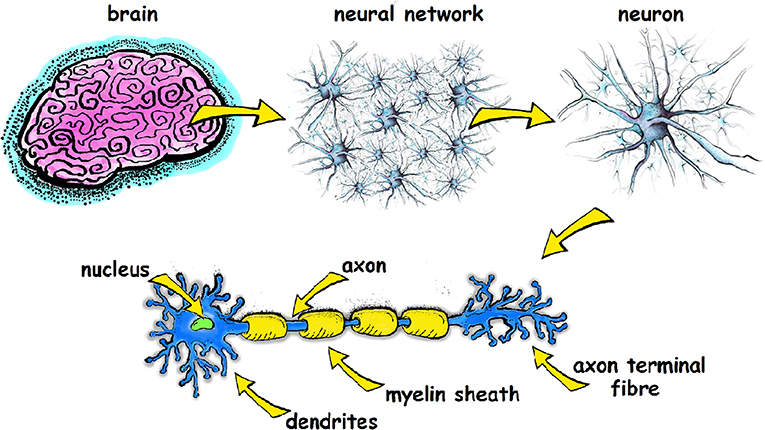

Our brains have about 86 billion neurons, all connected in a complex neural network.
Each neuron has a cell body, containing the nucleus, and extensions from the cell body called the axon and dendrites. Dendrites receive electrical signals coming into the cell, while the axon transmits an electrical signal away from the cell, toward other neurons.

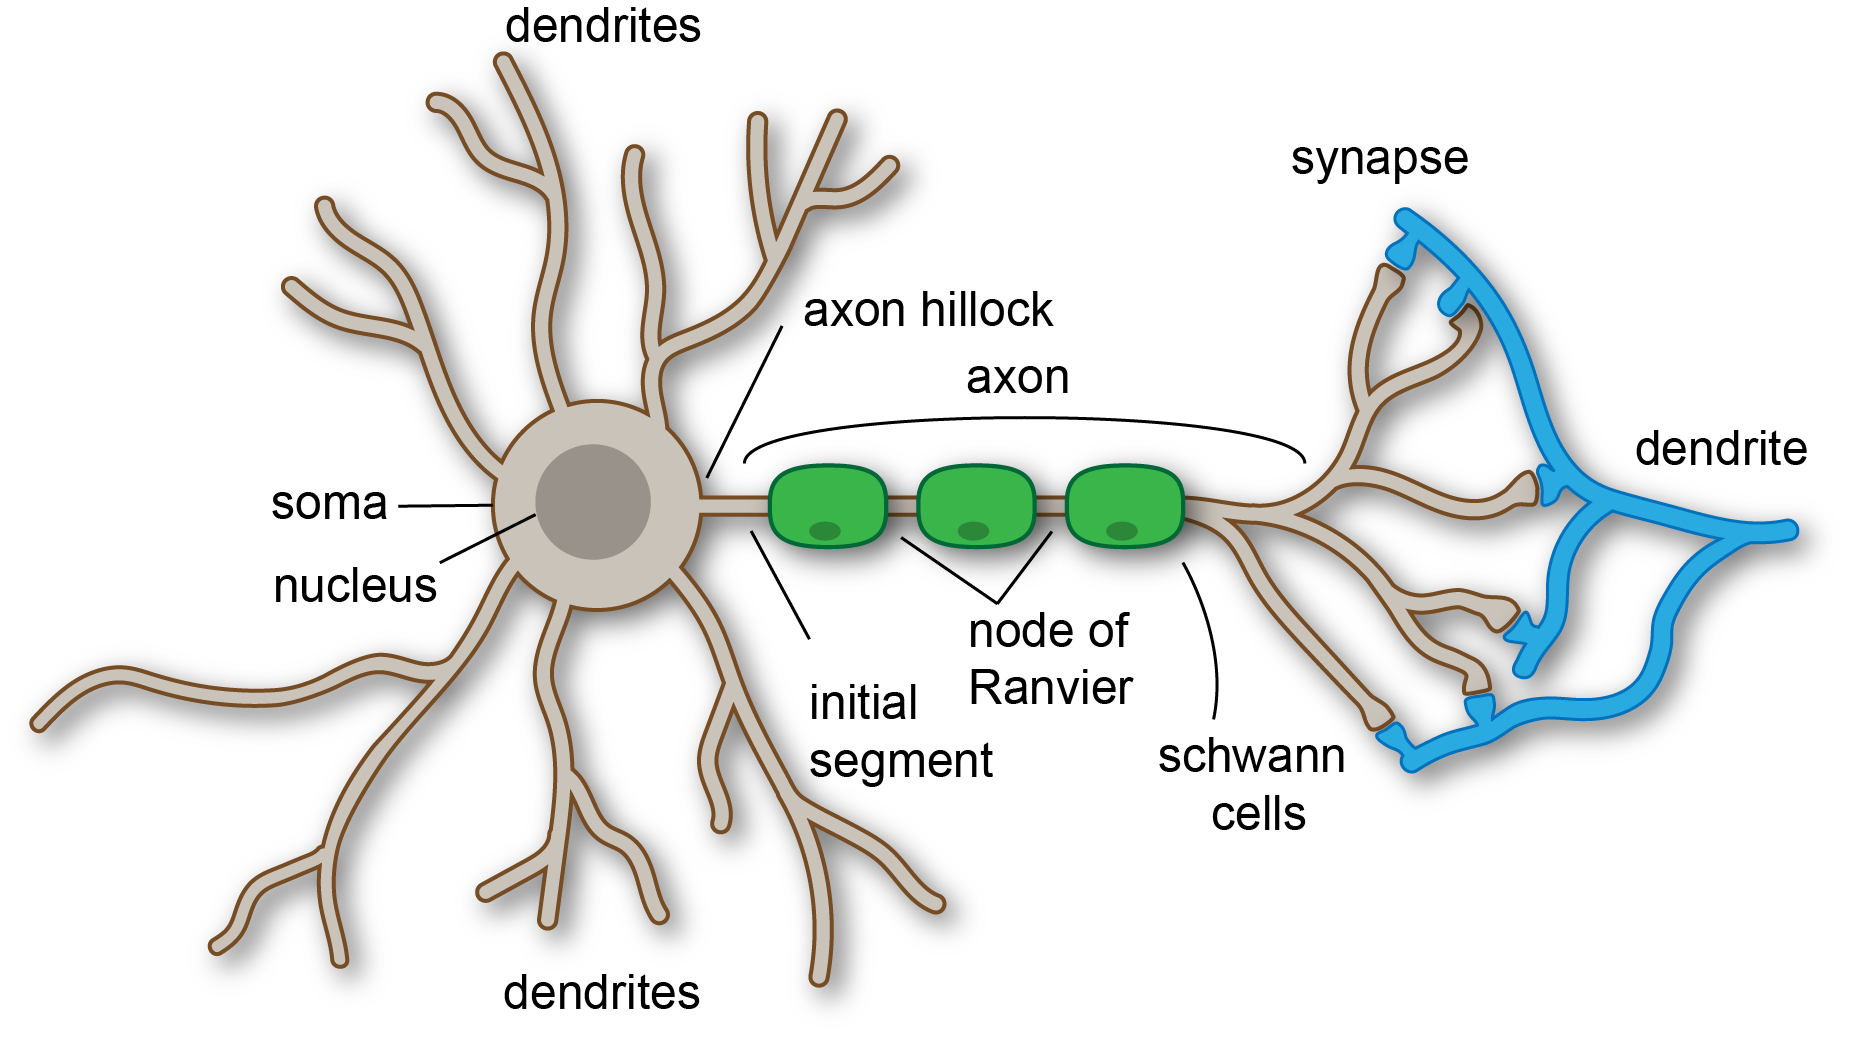

**Soma (Cell Body)**
> Processes incoming signals, generates outgoing signals (action potentials) if the input is sufficient, and maintains cellular health. The soma is responsible for maintaining the cell's health and functionality.

**Nucleus**
> Regulates gene expression, controls protein synthesis, and ensures the neuron's genetic information is preserved and used correctly. The nucleus acts as the control center of the neuron.

Together, the soma and nucleus ensure the neuron's proper function, enabling it to communicate effectively with other neurons and perform its role in the nervous system.

**Dendrites**
> Dendrites are tree-like extensions at the beginning of a neuron that receive information from other neurons (via synapses). They act as the input regions of the neuron, collecting signals from other neurons and conveying this information to the cell body (soma).

**Axon**
> The axon is a long, slender projection that extends from the cell body of the neuron. It transmits electrical impulses (action potentials) away from the cell body to other neurons, muscles, or glands.

**Synapses**
> Synapses are the junctions between the axon terminals of one neuron and the dendrites or cell body of another neuron. They facilitate communication between neurons.

#### Interactions
1) Signal Reception: Dendrites receive signals from other neurons via synapses. 
2) Signal Processing: The cell body (soma) processes the received signals. If the combined signal is strong enough, it generates an action potential.
3) Signal Transmission: The action potential travels down the axon to the synaptic terminals.
4) Signal Transfer: At the synapses, the electrical signal is converted into a chemical signal through the release of neurotransmitters, which then bind to receptors on the next neuron, continuing the signal transmission process.

### Artificial Neural Network
An artificial neural network processes input data as numerical vectors through interconnected nodes (digital neurons), which use activation functions to transform and analyze the information. As the network trains on more data, it iteratively adjusts the connection strengths (weights) between these nodes, improving its ability to detect patterns or make predictions. This learning process is loosely inspired by how biological brains adapt synaptic connections through experience, though the analogy is simplified

<hr>

## The Math of Neural Network

### ⭕️ Weighted Sum

The first step in the neural computation process involves aggregating the inputs to a neuron. The input data in the form of vector $x$ usually consist of $d$ features. Each input feature $x_ i$ will be multipilied by their respective weights $w_ i$, and then adding a bias term $b$. This operation is known as the weighted sum or linear combination. 

$$
\displaystyle  \displaystyle \hat{y} = \displaystyle  f(z)\quad \text {where } z= b + \sum _{i=1}^ d x_ i w_ i
$$

- $z$ is the weighted sum,
- $w_ i$​ represents the weight associated with the i-th input feature,
- $x_ i$​ is the i-th input feature to the neuron,
- $d$ total features in input $x$
- $b$ is the bias term, a unique parameter that allows adjusting the output along with the weighted sum.

The weighted sum is crucial because it constitutes the raw input signal to a neuron before any non-linear transformation. It allows the network to perform a linear transformation of the inputs, adjusting the importance (weight) of each input in the neuron’s output.


### ⭕️ Activation Functions

An activation function in a neural network is a mathematical function applied to the output of a neuron. These functions determine whether a neuron “fires” or activates, influencing the flow of information throughout the network. Without them, neural networks would simply be linear models, incapable of complex learning. Here are some key activation functions...

#### Sigmoid Activation Function

This function squeezes its input into a narrow range between 0 and 1. It’s like taking any value, no matter how large or small, and translating it into a probability.

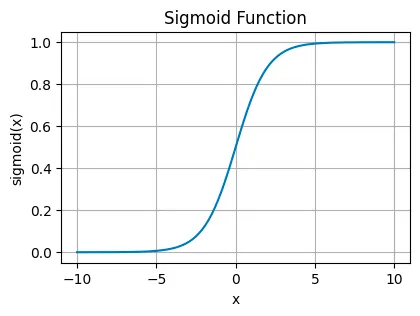

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

where:
- $ \sigma(x) $ is the output of the sigmoid function.
- $ x $ is the input to the function.
- $ e $ is the base of the natural logarithm (approximately equal to 2.71828).


You’ll see sigmoid functions in the final layer of binary classification networks, where you need to decide between two options — yes or no, true or false, 1 or 0.

#### Hyperbolic Tangent Function (tanh)

tanh stretches the output range to between -1 and 1. This centers the data around 0, making it easier for layers down the line to learn from it. It’s often found in the hidden layers, helping to model more complex data relationships by balancing the input signal.

$$ f(x) = \tanh(x) = \frac{2}{1 + e^{-2x}} - 1 $$

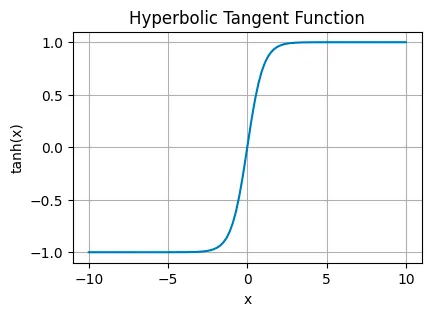

#### Rectified Linear Unit (ReLU)

ReLU is an improved version of sigmoid that passes positive values unchanged (allowing more varioations beyond binary 1) but blocks negatives, turning them to zero. This simplicity makes it very efficient and helps overcome some tricky problems in training convolutional neural networks (CNNs) and deep learning models.

$$ f(x) = max (0, x) $$

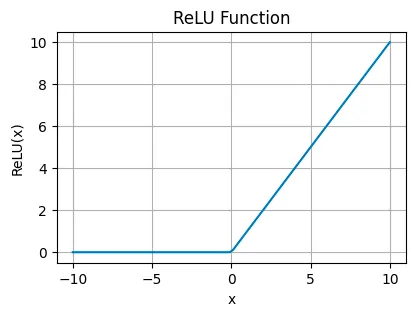

**Leaky Rectified Linear Unit (Leaky ReLU)** is a tweak to ReLU used in cases where the network might suffer from “dead neurons,” ensuring all parts of the network stay active over time. Basically Leaky ReLU allows a tiny, non-zero gradient when the input is less than zero (negative), which keeps neurons alive and kicking even when they’re not actively firing.

$$ f(x) = max (\alpha x, x) $$

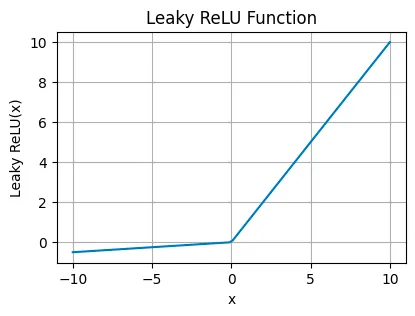

#### Exponential Linear Unit (ELU)

ELU smooths out the function for negative inputs (using a parameter α for scaling), allowing for negative outputs but with a gentle curve. This can help the network maintain a mean activation closer to zero, improving learning dynamics. Useful in deeper networks where ReLU’s sharp threshold could slow down learning.

The mathematical expression for ELU (Exponential Linear Unit) activation function is defined as:

$$ 
    f(x) = \begin{cases} 
    x & \text{if } x > 0 \\
    \alpha (e^x - 1) & \text{otherwise}
    \end{cases} 
$$

where $ \alpha $ is a parameter that controls the value to which an ELU saturates for negative net inputs.

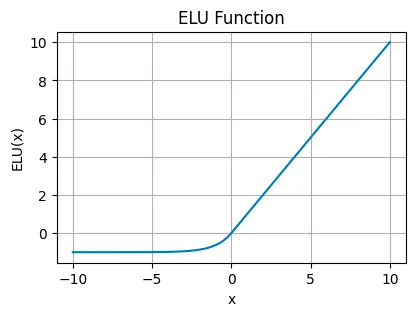

#### Softmax Function

The softmax function turns logits, the raw output scores from the neurons, into probabilities by exponentiating and normalizing them. It ensures that the output values sum up to one, making them directly interpretable as probabilities. It’s the go-to for the output layer in multi-class classification problems, where each neuron corresponds to a different class, and you want to pick the most likely one.

$$ f(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}} $$

where:
- $ f(x)_i $ is the output of the softmax function for the $ i $-th element.
- $ x_i $ is the $ i $-th input element.
- The denominator is the sum of the exponentials of all input elements $ x_j $.

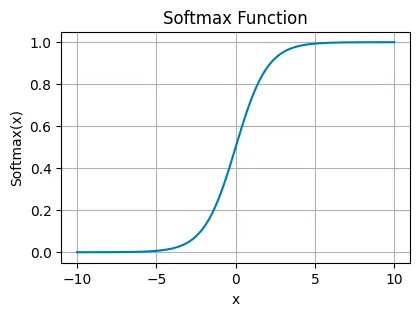

The softmax function is used in machine learning, particularly in classification tasks, to convert a vector of raw scores (logits) into probabilities.

### ⭕️ Backpropagation

Backpropagation, short for “backward propagation of errors,” is a method for efficiently calculating the gradient of the loss function concerning all weights in the network. It consists of two main phases: a forward pass, where the input data is passed through the network to generate an output, and a backward pass, where the output is compared to the target value, and the error is propagated back through the network to update the weights.

The essence of backpropagation is the chain rule of calculus, which is used to calculate the gradients of the loss function for each weight by multiplying the gradients of the layers behind it. This process reveals how much each weight contributes to the error, providing a clear path for its adjustment.

### ⭕️ Improvements or Optimization (Gradient Descent)
#### Weight and Bias Updates

While the basic idea of Gradient Descent is simple — take small steps in the direction that reduces error the most by updating the weights and biases.

$$
W_1 = W_1 - \eta \frac{\partial L}{\partial W_1}
$$
$$
b_1 = b_1 - \eta \frac{\partial L}{\partial b_1}
$$
$$
W_2 = W_2 - \eta \frac{\partial L}{\partial W_2}
$$
$$
b_2 = b_2 - \eta \frac{\partial L}{\partial b_2}
$$

- $ \eta $: Learning rate.
- We subtract the product of the learning rate and the gradients from the current weights and biases to minimize the loss.

There are a few well known Graident Descent appraoches

##### <u>Stochastic Gradient Descent (SGD)</u>

Stochastic Gradient Descent (SGD) takes the core idea of gradient descent but changes the approach by using just one training example at a time to calculate the gradient and update the weights. This method is similar to making decisions based on quick, individual observations rather than waiting to gather everyone’s opinion. It can make the learning process much faster because the model updates more frequently and with less computational burden.

##### <u>Adam (Adaptive Moment Estimation)</u>
Adam, short for Adaptive Moment Estimation, is like the wise advisor to SGD’s youthful energy. It takes the concept of adjusting weights based on the data’s gradient but does so with a more sophisticated, personalized approach for each parameter in the model. Adam combines ideas from two other gradient descent improvements, AdaGrad and RMSProp, to adapt the learning rate for each weight in the network based on the first (mean) and second (uncentered variance) moments of the gradients.

## Step-by-step math example
Here is a step-by-step details on our neural network with one hidden layer will perform a forward pass and backpropagation. The network has two layers: a hidden layer with 64 neurons and an output layer with 10 neurons. The input is a vector of size 64 (8x8 pixels), and the output is a vector of size 10 (probabilities for digits 0-9).

![Neural Network](_asset/images/nn_hero_small.gif)

**🔘 Forward Pass**: Calculate the output of the network using the current weights.

**🔘 Compute Loss**: Determine the difference between the predicted output and the actual output using a loss function (e.g., mean squared error, cross-entropy).

**🔘 Backward Pass (Backpropagation)**:
   - **Output Layer**: Compute the gradient of the loss with respect to the output layer's inputs.
   - **Hidden Layers**: Compute the gradient of the loss with respect to the hidden layer's inputs by propagating the error backward through the network.
   - **Weight Updates**: Use the gradients to update the weights of the network.

<br>

**Notation**
- $ x $: Input
- $ y $: Actual output
- $ \hat{y} $: Predicted output
- $ W_1, W_2 $: Weights for hidden and output layers respectively
- $ b_1, b_2 $: Biases for hidden and output layers respectively
- $ h $: Output of hidden layer
- $ L $: Loss function


### 🔘 Forward Pass
In the forward pass, we compute the outputs of the network layer by layer using the current weights and biases.

#### → Step 1. **Hidden Layer**:
   $$
   z_1 = W_1 \cdot x + b_1
   $$
   - $ W_1 $: Weight matrix for the hidden layer.
   - $ x $: Input vector.
   - $ b_1 $: Bias vector for the hidden layer.
   - $ z_1 $: Linear combination of input weights and bias before activation.

#### → Step 2. **Activation of Hidden Layer**:
   $$
   h = \sigma(z_1)
   $$
   - $ \sigma $: Activation function (e.g., sigmoid, ReLU).
   - $ h $: Output of the hidden layer after applying the activation function to $ z_1 $.

#### → Step 3. **Output Layer**:
   $$
   z_2 = W_2 \cdot h + b_2
   $$
   - $ W_2 $: Weight matrix for the output layer.
   - $ h $: Output from the hidden layer.
   - $ b_2 $: Bias vector for the output layer.
   - $ z_2 $: Linear combination of hidden layer outputs and bias before activation.

#### → Step 4. **Activation of Output Layer**:
   $$
   \hat{y} = f(z_2)
   $$
   - $ f $: Activation function for the output layer (e.g., softmax for classification).
   - $ \hat{y} $: Predicted output.

#### → Step 5. **Loss Calculation**:
   $$
   L = \text{Loss}(\hat{y}, y)
   $$
   - $ L $: Loss value.
   - $ y $: Actual output.
   - $\text{Loss}$: Loss function (e.g., mean squared error, cross-entropy loss).

### 🔘 Backward Pass
In the backward pass, we compute the gradients of the loss function with respect to each weight and bias by propagating the error backward through the network.

#### → Step 6. **Gradient of Loss with respect to Output Layer**:
   $$
   \frac{\partial L}{\partial \hat{y}} = \frac{\partial \text{Loss}(\hat{y}, y)}{\partial \hat{y}}
   $$
   - This is the partial derivative of the loss function with respect to the predicted output.

**Lets understand a bit deeper**

The mathematical expression for $\frac{\partial \text{Loss}(\hat{y}, y)}{\partial \hat{y}}$ can be solved depending on specific form of the loss function $\text{Loss}(\hat{y}, y)$ being used. Here are the expressions for two common loss functions:

- **Mean Squared Error (MSE)**
$$ \text{Loss}(\hat{y}, y) = \frac{1}{2} (\hat{y} - y)^2 $$

The partial derivative with respect to $\hat{y}$ is:
$$ \frac{\partial \text{Loss}(\hat{y}, y)}{\partial \hat{y}} = \hat{y} - y $$

- **Cross-Entropy Loss**
$$ \text{Loss}(\hat{y}, y) = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})] $$

The partial derivative with respect to $\hat{y}$ is:
$$ \frac{\partial \text{Loss}(\hat{y}, y)}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}} $$

#### → Step 7. **Gradient of Output Layer Activation**:
   $$
   \frac{\partial \hat{y}}{\partial z_2} = f'(z_2)
   $$
   - This is the derivative of the output activation function with respect to its input $ z_2 $.

The mathematical expression $\frac{\partial \hat{y}}{\partial z_2} = f'(z_2)$ represents the derivative of the output $\hat{y}$ with respect to the input $z_2$, where $f$ is an activation function applied to $z_2$. The derative can be further expanded based on activation function

1. **Sigmoid Function**
   $$ f(z_2) = \frac{1}{1 + e^{-z_2}} $$
   $$ f'(z_2) = f(z_2) \cdot (1 - f(z_2)) $$

2. **ReLU (Rectified Linear Unit)**
   $$ f(z_2) = \max(0, z_2) $$
   $$ f'(z_2) = \begin{cases} 
   1 & \text{if } z_2 > 0 \\
   0 & \text{if } z_2 \leq 0 
   \end{cases} $$

3. **Tanh Function**
   $$ f(z_2) = \tanh(z_2) $$
   $$ f'(z_2) = 1 - \tanh^2(z_2) $$

4. **Softmax Function**
   For the $i$-th component of the softmax function:
   $$ f_i(z_2) = \frac{e^{z_{2i}}}{\sum_{j} e^{z_{2j}}} $$
   The derivative is more complex and involves the Jacobian matrix:
   $$ \frac{\partial f_i}{\partial z_{2j}} = f_i(z_2) (\delta_{ij} - f_j(z_2)) $$
   where $\delta_{ij}$ is the Kronecker delta.




In [1]:
import sympy as sp

# Define the symbol
z_2 = sp.symbols('z_2')

# Sigmoid function and its derivative
sigmoid = 1 / (1 + sp.exp(-z_2))
sigmoid_derivative = sp.diff(sigmoid, z_2)
print(f"Sigmoid Derivative: {sigmoid_derivative}")

# ReLU function and its derivative
relu = sp.Piecewise((0, z_2 <= 0), (z_2, z_2 > 0))
relu_derivative = sp.diff(relu, z_2)
print(f"ReLU Derivative: {relu_derivative}")

# Tanh function and its derivative
tanh = sp.tanh(z_2)
tanh_derivative = sp.diff(tanh, z_2)
print(f"Tanh Derivative: {tanh_derivative}")

Sigmoid Derivative: exp(-z_2)/(1 + exp(-z_2))**2
ReLU Derivative: Piecewise((0, z_2 <= 0), (1, True))
Tanh Derivative: 1 - tanh(z_2)**2


#### → Step 8. **Gradient of Loss with respect to Output Layer Input**:
   
$$
\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2}
$$

- Using the chain rule, we multiply the gradient of the loss with respect to the output by the gradient of the output with respect to $ z_2 $.

#### → Step 9. **Gradient of Loss with respect to Weights and Biases of Output Layer**:
   
$$
\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial z_2} \cdot h^T
$$
$$
\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial z_2}
$$

- For the weights $ W_2 $, we multiply the gradient with respect to $ z_2 $ by the transpose of the hidden layer output $ h $.
- For the biases $ b_2 $, the gradient is just the gradient with respect to $ z_2 $.

#### → Step 10. **Gradient of Loss with respect to Hidden Layer**:
   
$$
\frac{\partial L}{\partial h} = W_2^T \cdot \frac{\partial L}{\partial z_2}
$$
   
- We propagate the error back to the hidden layer by multiplying the transpose of the output layer weights $ W_2 $ by the gradient with respect to $ z_2 $.

#### → Step 11. **Gradient of Hidden Layer Activation**:
   
$$
\frac{\partial h}{\partial z_1} = \sigma'(z_1)
$$

- This is the derivative of the hidden layer activation function with respect to its input $ z_1 $.

#### → Step 12. **Gradient of Loss with respect to Hidden Layer Input**:
    
$$
\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial h} \cdot \frac{\partial h}{\partial z_1}
$$

- Using the chain rule, we multiply the gradient with respect to the hidden layer output by the gradient of the hidden layer output with respect to $ z_1 $.

#### → Step 13. **Gradient of Loss with respect to Weights and Biases of Hidden Layer**:
    
$$
\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_1} \cdot x^T
$$
$$
\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}
$$

- For the weights $ W_1 $, we multiply the gradient with respect to $ z_1 $ by the transpose of the input $ x $.
- For the biases $ b_1 $, the gradient is just the gradient with respect to $ z_1 $.

<hr>

## Python Code
A simple neural network from scratch in Python with one hidden layer. The objective of this network is to accept an 8x8 pixel image ([MNIST](https://en.wikipedia.org/wiki/MNIST_database)) of a digit and output the probability of the digit being 0-9

In [2]:
import numpy as np

class NeuralNetwork:
    """
    A simple neural network with one hidden layer.

    Parameters:
    -----------
    input_size: int
        The number of input features
    hidden_size: int
        The number of neurons in the hidden layer
    output_size: int
        The number of neurons in the output layer
    loss_func: str
        The loss function to use. Options are 'mse' for mean squared error, 'log_loss' for logistic loss, and 'categorical_crossentropy' for categorical crossentropy.
    """
    
    def __init__(self, input_size, hidden_size, output_size, loss_func='mse'):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.loss_func = loss_func

        # Initialize weights and biases
        self.weights_hidden_layer = np.random.randn(self.input_size, self.hidden_size)
        self.bias_hidden_layer = np.zeros((1, self.hidden_size))
        self.weights_output_layer = np.random.randn(self.hidden_size, self.output_size)
        self.bias_output_layer = np.zeros((1, self.output_size))

        # track loss
        self.train_loss = []
        self.test_loss = []

    def __str__(self):
        return f"Neural Network Layout:\nInput Layer: {self.input_size} neurons\nHidden Layer: {self.hidden_size} neurons\nOutput Layer: {self.output_size} neurons\nLoss Function: {self.loss_func}"

    def forward(self, X):
        """
        Perform forward propagation.
        
        Parameters:
        -----------
        X: numpy array
            The input data
        
        Returns:
        --------
        numpy array
            The predicted output
        """
        # Hidden layer
        self.z_hidden = np.dot(X, self.weights_hidden_layer) + self.bias_hidden_layer
        self.a_hidden = self.sigmoid(self.z_hidden)

        # Output layer
        self.z_output = np.dot(self.a_hidden, self.weights_output_layer) + self.bias_output_layer
        if self.loss_func == 'categorical_crossentropy':
            self.a_output = self.softmax(self.z_output)
        else:
            self.a_output = self.sigmoid(self.z_output)

        return self.a_output
    
    def backward(self, X, y, learning_rate):
        """
        Perform backward propagation.
        
        Parameters:
        -----------
        X: numpy array
            The input data
        y: numpy array
            The target data
        learning_rate: float
            The learning rate
        """
        # Perform backpropagation
        m = X.shape[0]

        # Calculate gradients for output layer input
        if self.loss_func == 'mse':
            self.d_output = self.a_output - y
        elif self.loss_func == 'log_loss':
            self.d_output = -(y/self.a_output - (1-y)/(1-self.a_output))
        elif self.loss_func == 'categorical_crossentropy':
            self.d_output = self.a_output - y
        else:
            raise ValueError('Invalid loss function')
        
        # Calculate gradients of weights and biases for output layer
        self.d_weights_output_layer = np.dot(self.a_hidden.T, self.d_output) / m
        self.d_bias_output_layer = np.sum(self.d_output, axis=0, keepdims=True) / m
        # Calculate gradients of hidden layer input, weights, and biases
        self.d_hidden = np.dot(self.d_output, self.weights_output_layer.T) * self.sigmoid_derivative(self.a_hidden)
        self.d_weights_hidden_layer = np.dot(X.T, self.d_hidden) / m
        self.d_bias_hidden_layer = np.sum(self.d_hidden, axis=0, keepdims=True) / m
        
        # Update weights and biases
        self.weights_output_layer -= learning_rate * self.d_weights_output_layer
        self.bias_output_layer -= learning_rate * self.d_bias_output_layer
        self.weights_hidden_layer -= learning_rate * self.d_weights_hidden_layer
        self.bias_hidden_layer -= learning_rate * self.d_bias_hidden_layer


    def sigmoid(self, z):
        """
        Sigmoid activation function.
        
        Parameters:
        -----------
        z: numpy array
            The input data
        
        Returns:
        --------
        numpy array
            The output of the sigmoid function
        """
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, x):
        """
        Sigmoid activation function derivative.
        
        Parameters:
        -----------
        x: numpy array
            The input data
        
        Returns:
        --------
        numpy array
            The output of the sigmoid function derivative
        """
        return x * (1 - x)
    
    def softmax(self, z):
        """
        Softmax activation function.
        
        Parameters:
        -----------
        z: numpy array
            The input data
        
        Returns:
        --------
        numpy array
            The output of the softmax function
        """
        exps = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exps/np.sum(exps, axis=1, keepdims=True)    

### Trainer Class

The code below introduces a Trainer class designed to train our neural network model. It encapsulates everything needed to conduct training, including executing training cycles (epochs), calculating loss, and adjusting the model's parameters through backpropagation based on the loss.

In [3]:
class Trainer:
    """
    A class to train a neural network.

    Parameters:
    -----------
    model: NeuralNetwork
        The neural network model to train
    loss_func: str
        The loss function to use. Options are 'mse' for mean squared error, 'log_loss' for logistic loss, and 'categorical_crossentropy' for categorical crossentropy.
    """
    def __init__(self, model, loss_func='mse'):
        self.model = model
        self.loss_func = loss_func
        self.train_loss = []
        self.test_loss = []

    def calculate_loss(self, y_true, y_pred):
        """
        Calculate the loss.

        Parameters:
        -----------
        y_true: numpy array
            The true output
        y_pred: numpy array
            The predicted output
        
        Returns:
        --------
        float
            The loss
        """
        if self.loss_func == 'mse':
            return np.mean((y_pred - y_true)**2)
        elif self.loss_func == 'log_loss':
            return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))
        elif self.loss_func == 'categorical_crossentropy':
            return -np.mean(y_true*np.log(y_pred))
        else:
            raise ValueError('Invalid loss function')

    def train(self, X_train, y_train, X_test, y_test, epochs, learning_rate):
        """
        Train the neural network.

        Parameters:
        -----------
        X_train: numpy array
            The training input data
        y_train: numpy array
            The training target output
        X_test: numpy array
            The test input data
        y_test: numpy array
            The test target output
        epochs: int
            The number of epochs to train the model
        learning_rate: float
            The learning rate
        """
        for _ in range(epochs):
            self.model.forward(X_train)
            self.model.backward(X_train, y_train, learning_rate)
            train_loss = self.calculate_loss(y_train, self.model.a_output)
            self.train_loss.append(train_loss)
            
            self.model.forward(X_test)
            test_loss = self.calculate_loss(y_test, self.model.a_output)
            self.test_loss.append(test_loss)

### Usage

Below code would load digits dataset, prepare it for training our neural network for a classification task. The process involves data preprocessing, model creation, training, and evaluation.

Accuracy: 93.06%


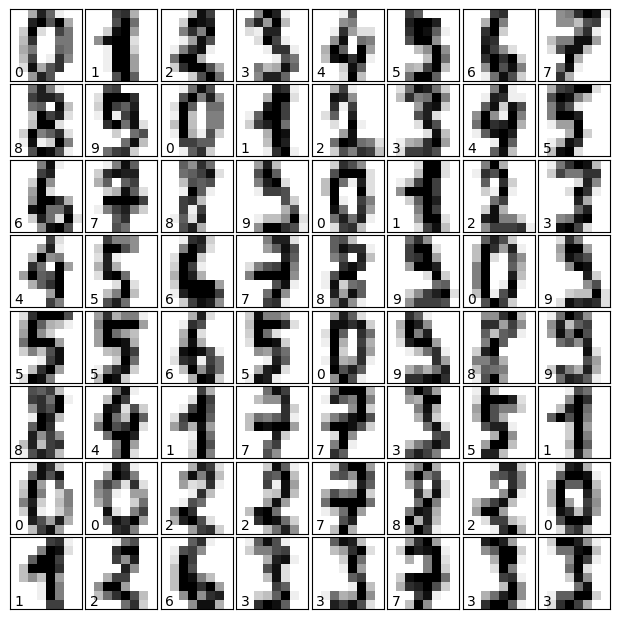

In [4]:
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from matplotlib import pyplot as plt

def show_digits(digits, n=64):
    fig = plt.figure(figsize=(6, 6))  # figure size in inches
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(n):
        ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
        ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
        # label the image with the target value
        ax.text(0, 7, str(digits.target[i]))

# Load the digits dataset
digits = load_digits()
show_digits(digits)

# Preprocess the dataset
scaler = MinMaxScaler()
X = scaler.fit_transform(digits.data)
y = digits.target

# One-hot encode the target output
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Create an instance of the NeuralNetwork class
input_size = X.shape[1]
hidden_size = 64
output_size = len(np.unique(y))
loss_func = 'categorical_crossentropy'
epochs = 1000
learning_rate = 0.1

nn = NeuralNetwork(input_size, hidden_size, output_size, loss_func)

trainer = Trainer(nn, loss_func)
trainer.train(X_train, y_train, X_test, y_test, epochs, learning_rate)

# Convert y_test from one-hot encoding to labels
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate the performance of the neural network
predictions = np.argmax(nn.forward(X_test), axis=1)
accuracy = np.mean(predictions == y_test_labels)
print(f"Accuracy: {accuracy:.2%}")

### Predict Single Digit

Input Digit 8x8 image vector (white=0.00, black=1.00) : 
+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+
|    Pix1    |    Pix2    |    Pix3    |    Pix4    |    Pix5    |    Pix6    |    Pix7    |    Pix8    |
+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+::::::::::::+
|    0.00    |    0.00    |    0.12    |    0.81    |    0.50    |    0.00    |    0.00    |    0.00    |
|    0.00    |    0.00    |    0.38    |    1.00    |    1.00    |    0.38    |    0.00    |    0.00    |
|    0.00    |    0.00    |    0.31    |    0.94    |    0.81    |    0.69    |    0.00    |    0.00    |
|    0.00    |    0.00    |    0.00    |    0.44    |    1.00    |    0.94    |    0.00    |    0.00    |
|    0.00    |    0.00    |    0.00    |    0.00    |    0.00    |    0.88    |    0.21    |    0.00    |
|    0.00    |    0.00    |    0.00    |    0.00    |    0.00    |    0.44    |    0.69    |   

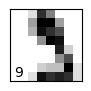

In [73]:
import numpy as np
from dataclasses import dataclass
import pandas as pd
from tabulate import tabulate
from prettytable import PrettyTable

def show_input_vector(vector):
    reshaped_X = vector.reshape(8, 8)
    df = pd.DataFrame(reshaped_X)
    fixed_width_df = df.map(lambda x: f"{x:5.2f}")

    t = PrettyTable(
        ['Pix1', 'Pix2', 'Pix3', 'Pix4', 'Pix5', 'Pix6', 'Pix7', 'Pix8'], 
        align='c', 
        horizontal_char=':',
        max_width=10, 
        min_width=10
    )   
    t.add_rows(fixed_width_df.values.tolist())
    print(t)

@dataclass
class SingleDigit:
   images: np.array
   target: np.array

test_idx = 31
X_single_input = X[test_idx]
y_single_label = y[test_idx]
singleDigit = SingleDigit(
    # Shape of digits.images is (samples_n, 8, 8) where 8x8 are pixels
    images = np.array([digits.images[test_idx]]),
    target = np.array([digits.target[test_idx]])
)

# nn.forward returns the probabilities (Softmax) accross 0-9
# argmax returns the max index value
predict = np.argmax(nn.forward(X_single_input), axis=1)

print(f"Input Digit 8x8 image vector (white=0.00, black=1.00) : ")
show_input_vector(X_single_input)
print(f"Predicted Value : ", predict[0])
print(f"Input Digit Image (8x8 pixels) with Label :")
show_digits(singleDigit, 1)